In [31]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df= pd.read_csv("train.csv")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [12]:
print(df.shape)

(9800, 18)


In [14]:
print(df.dtypes)

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object


In [16]:
df.isnull().sum()


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [21]:
print(df[['Sales']].describe())

              Sales
count   9800.000000
mean     230.769059
std      626.651875
min        0.444000
25%       17.248000
50%       54.490000
75%      210.605000
max    22638.480000


In [22]:
 print(df[['Sales']].median())

Sales    54.49
dtype: float64


In [26]:
print(df['Order Date'].dtype)

str


In [27]:
print(df['Order Date'].head())

0    08/11/2017
1    08/11/2017
2    12/06/2017
3    11/10/2016
4    11/10/2016
Name: Order Date, dtype: str


In [28]:
print(df['Order Date'].unique()[:10])

<StringArray>
['08/11/2017', '12/06/2017', '11/10/2016', '09/06/2015', '15/04/2018',
 '05/12/2017', '22/11/2016', '11/11/2015', '13/05/2015', '27/08/2015']
Length: 10, dtype: str


In [29]:
df['Order Date']=pd.to_datetime(df['Order Date'],dayfirst=True)

In [30]:
print(df['Order Date'].dtype)

datetime64[us]


In [44]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
print(monthly_sales.head())

Order Date
2015-01    14205.707
2015-02     4519.892
2015-03    55205.797
2015-04    27906.855
2015-05    23644.303
Freq: M, Name: Sales, dtype: float64


/lib/python3.14/site-packages/pandas/plotting/_matplotlib/core.py:599: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=self.figsize)


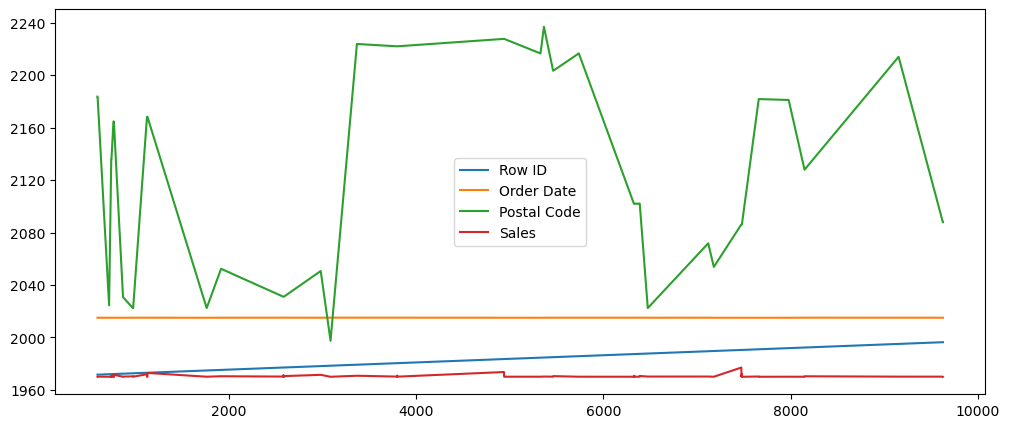

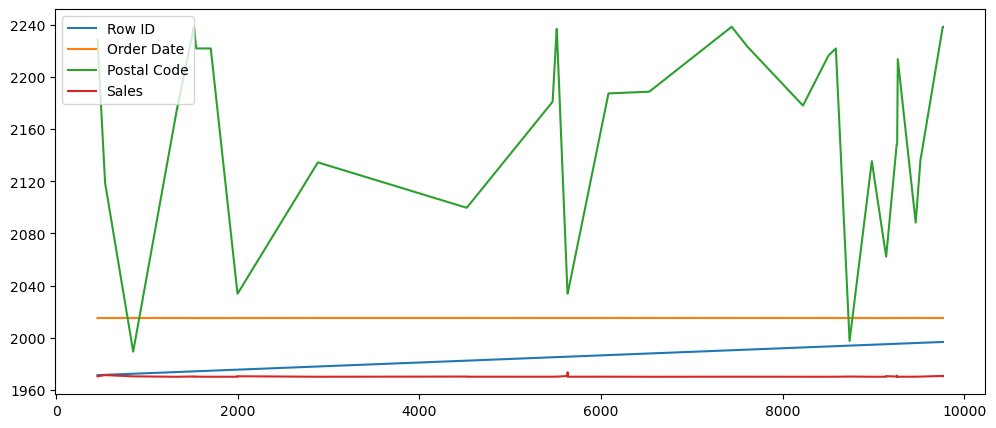

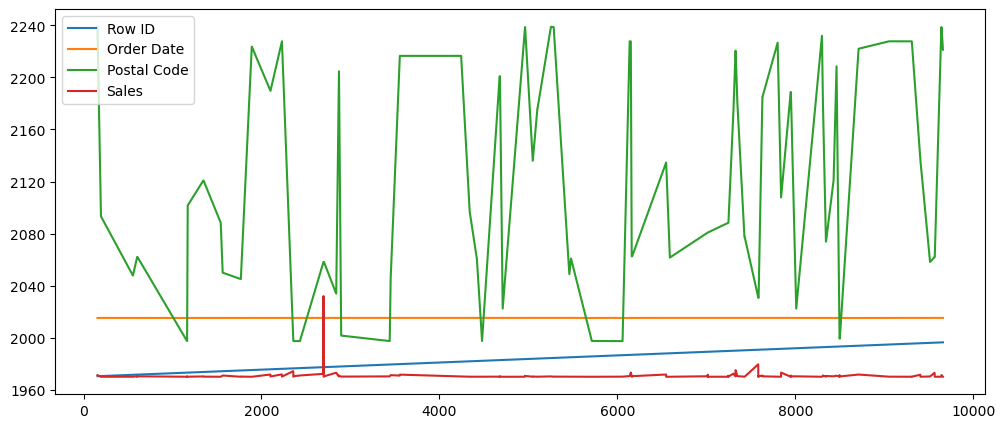

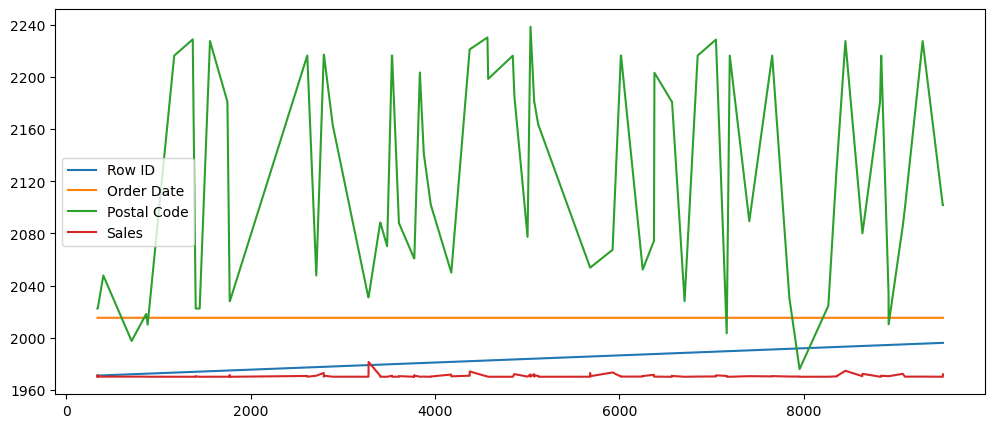

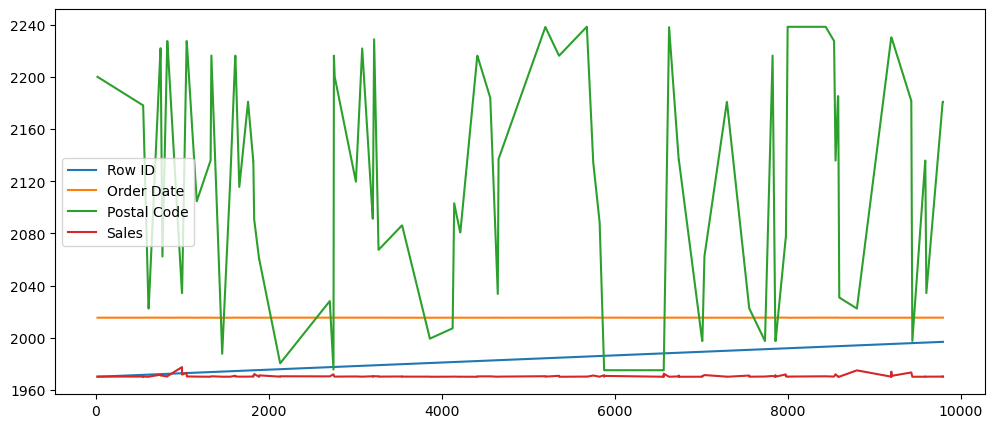

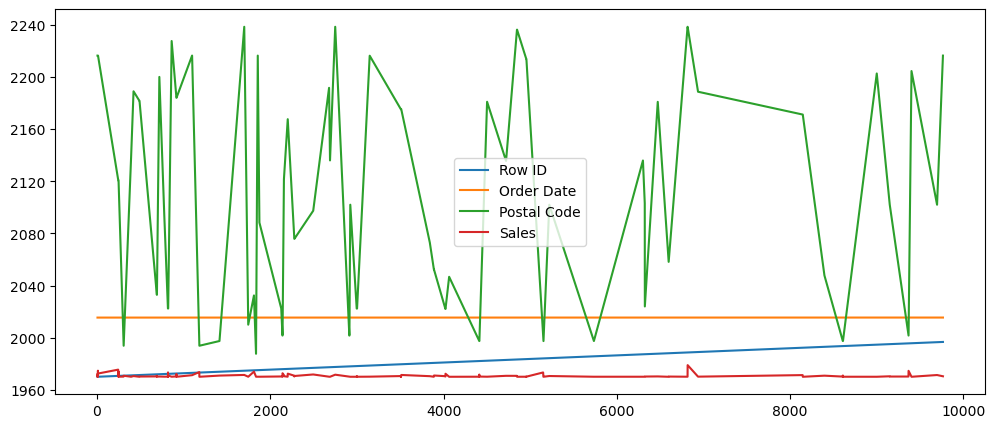

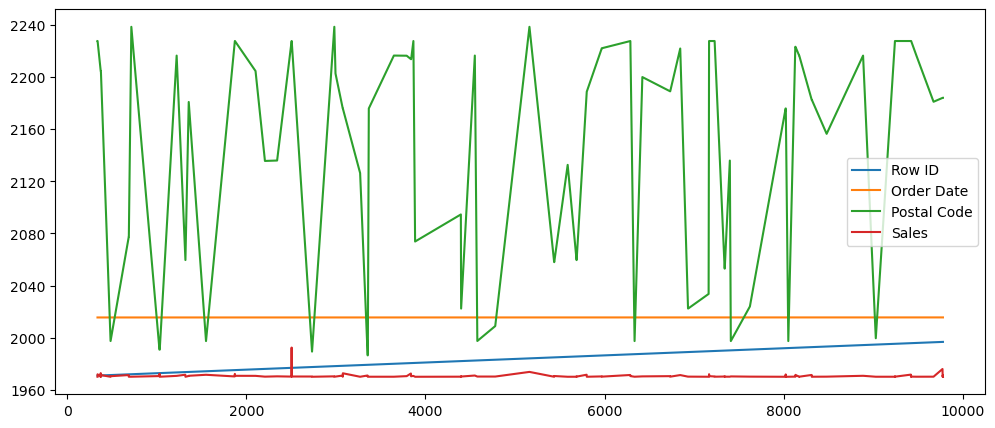

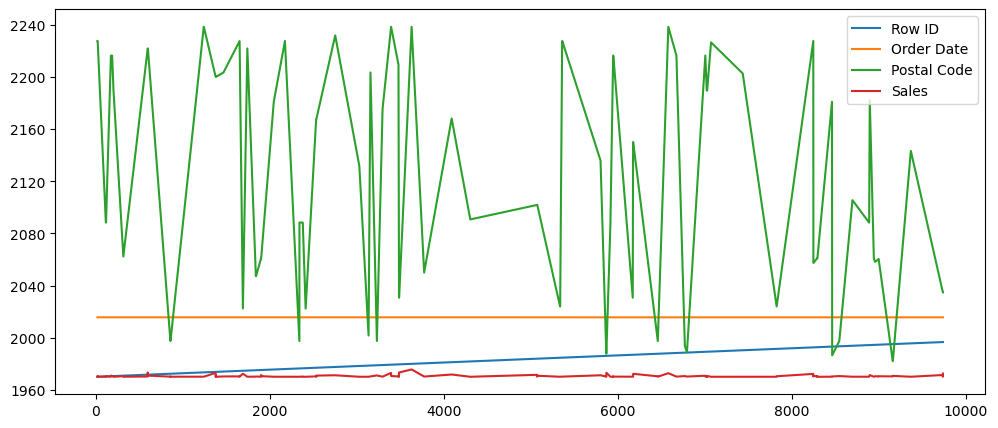

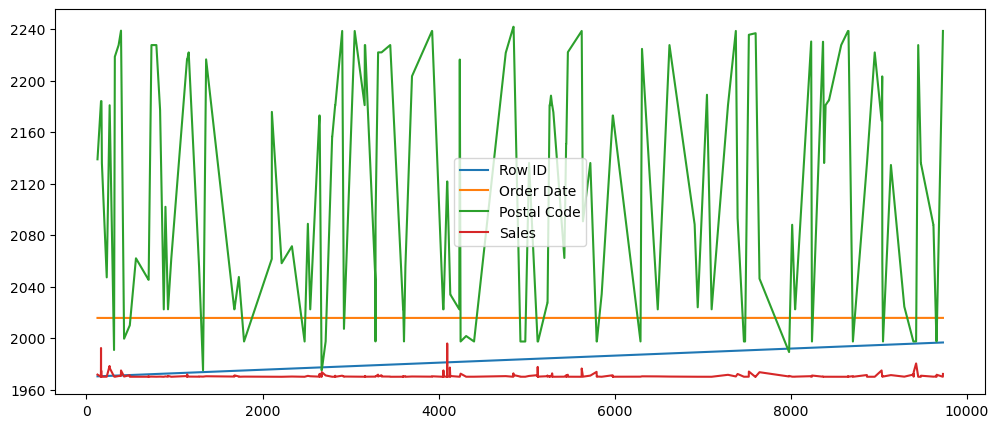

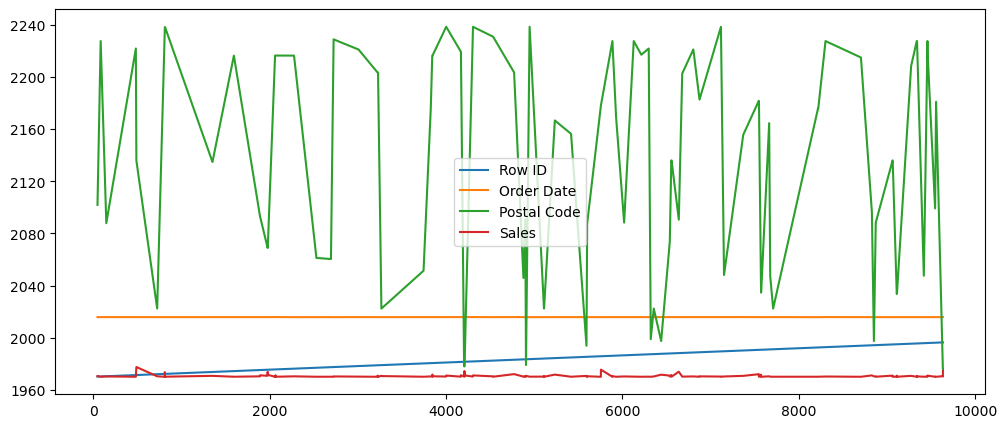

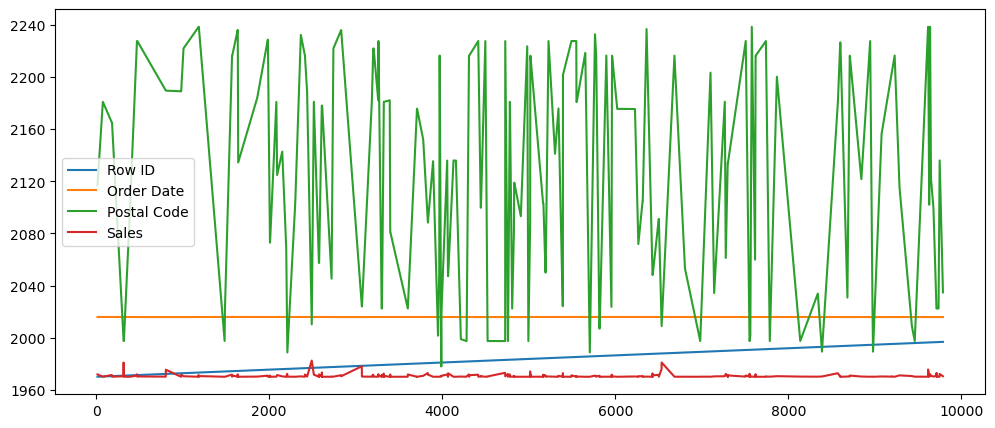

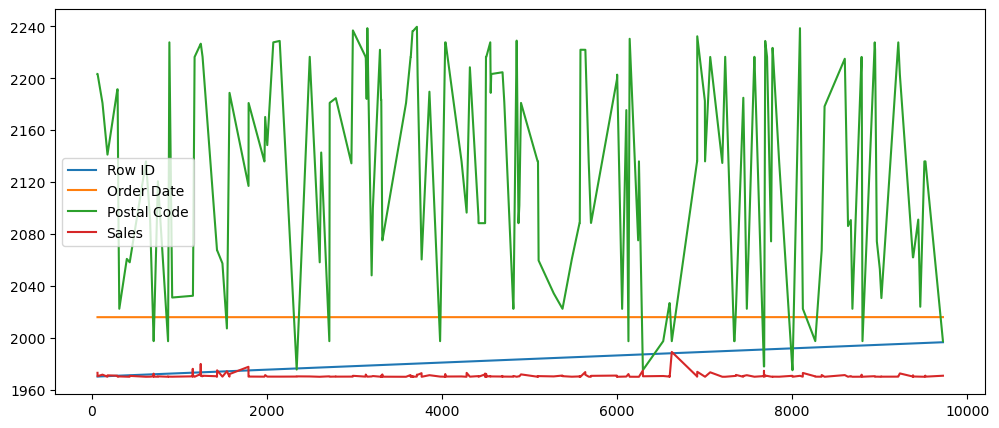

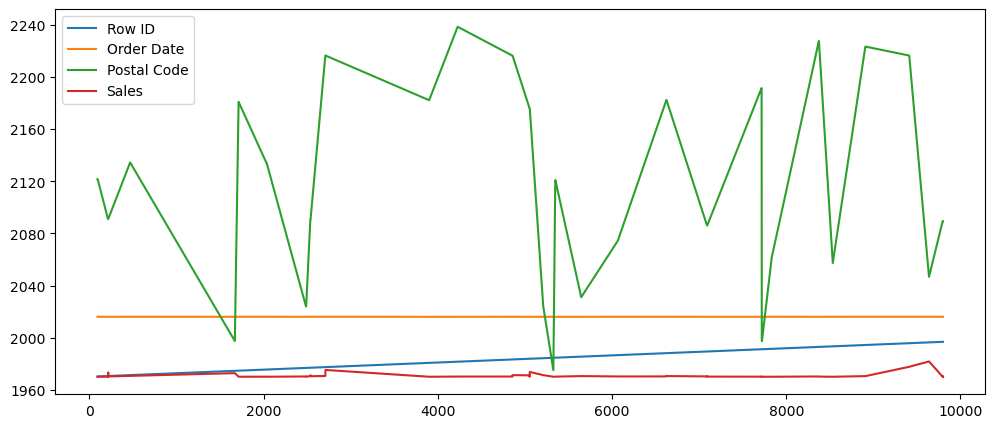

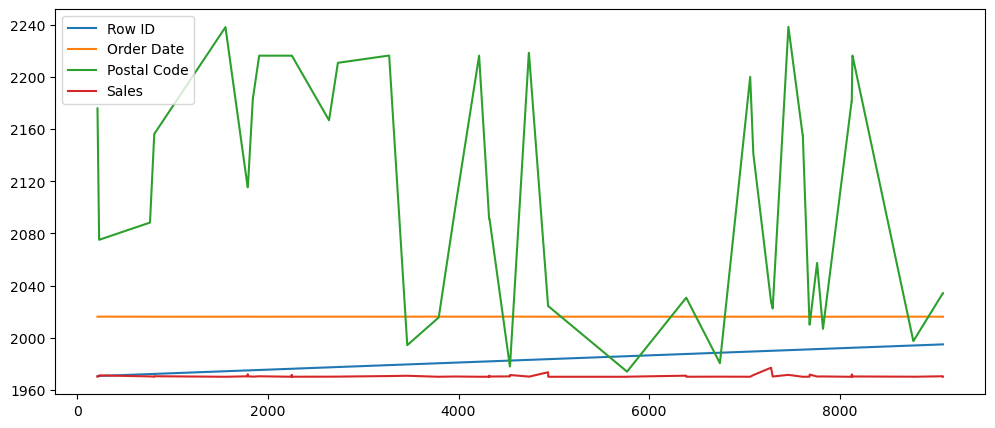

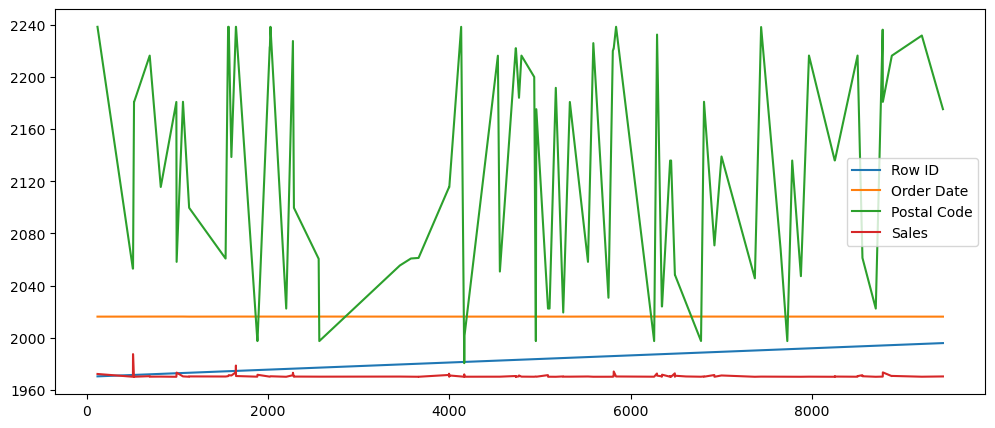

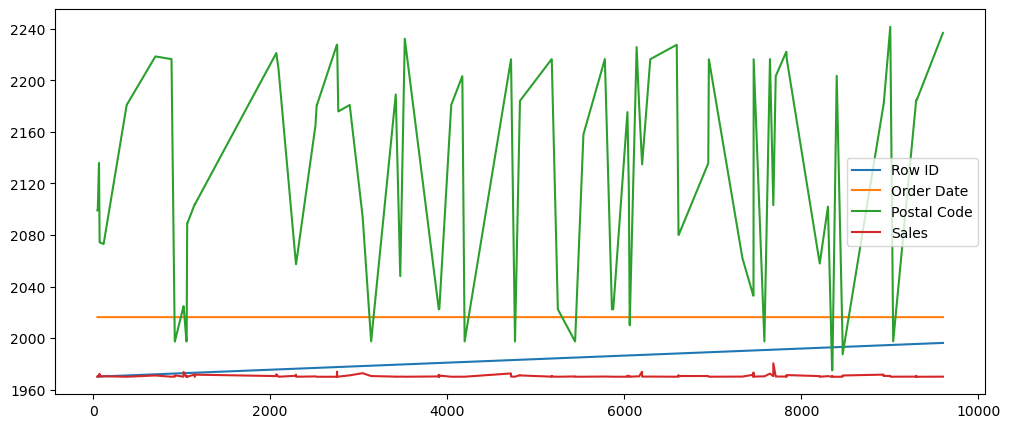

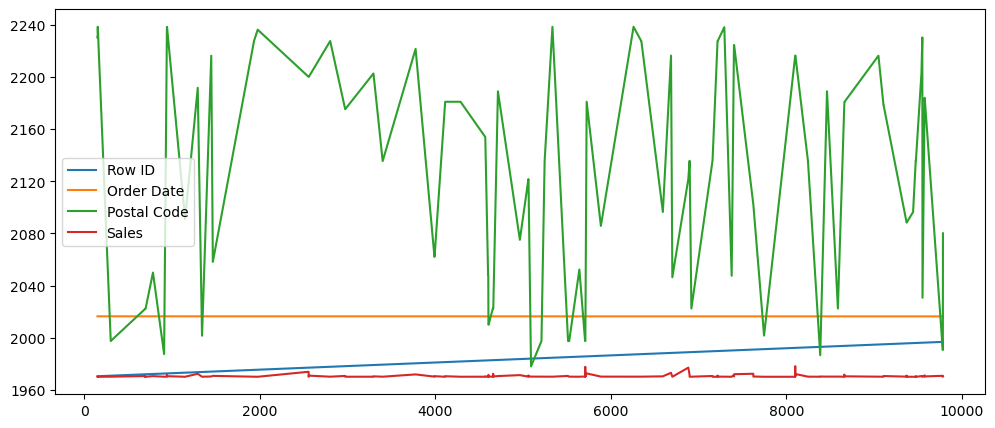

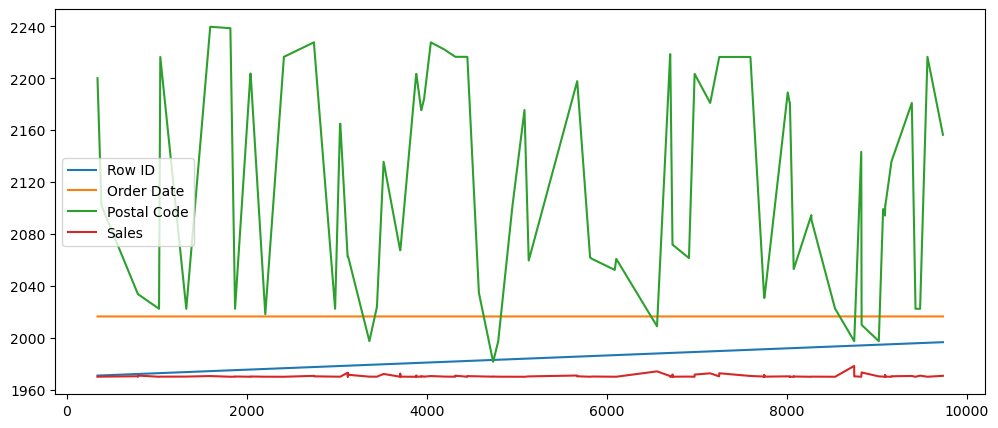

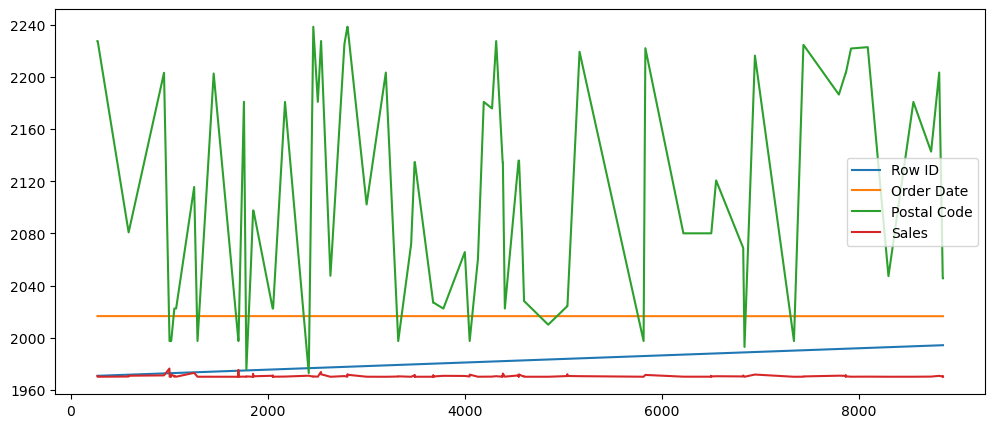

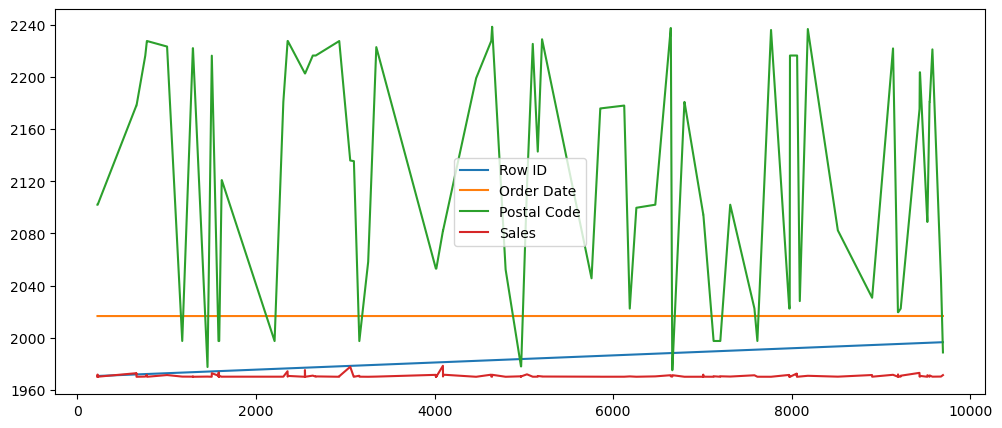

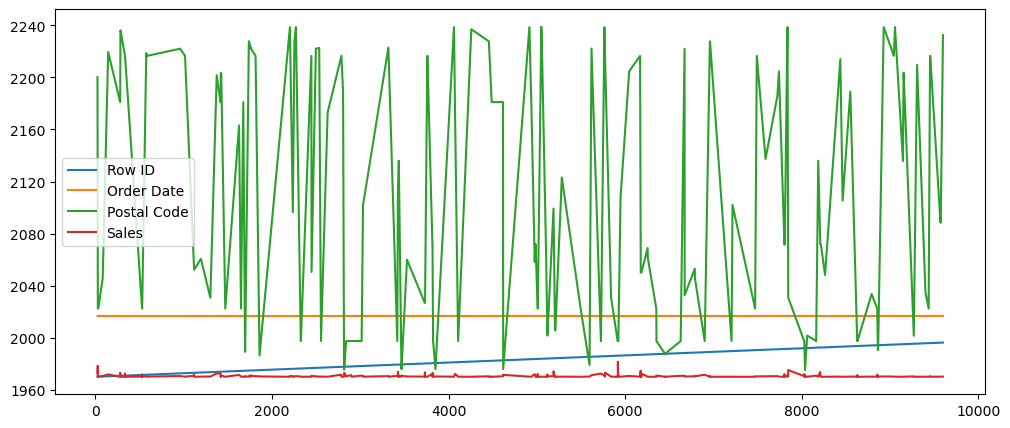

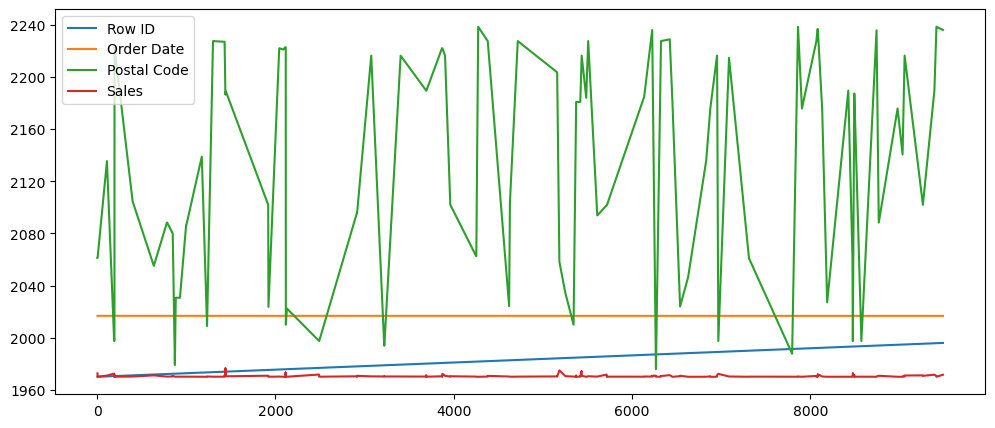

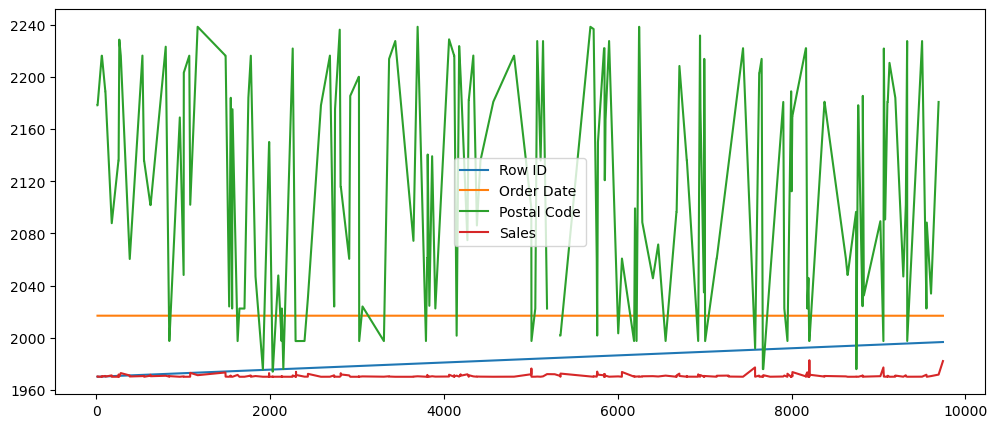

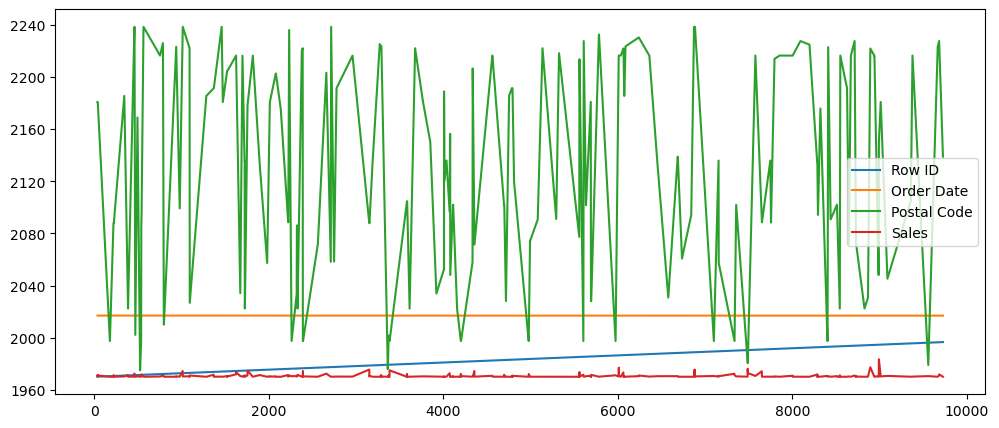

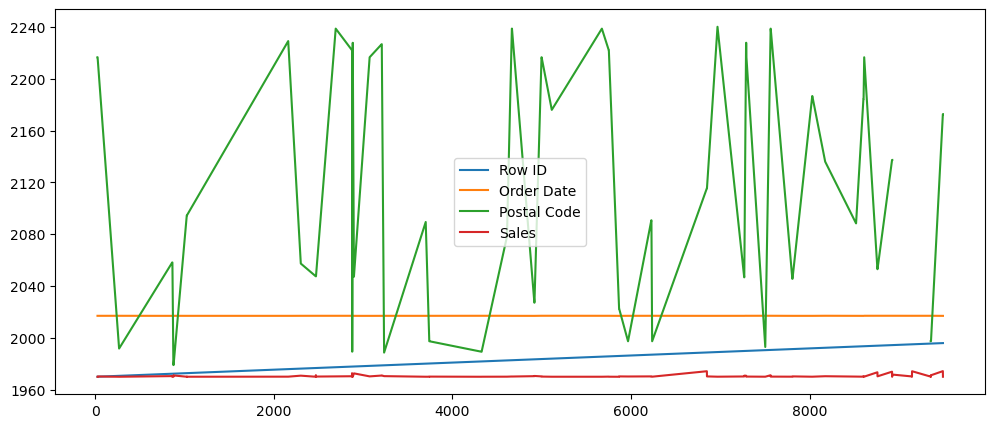

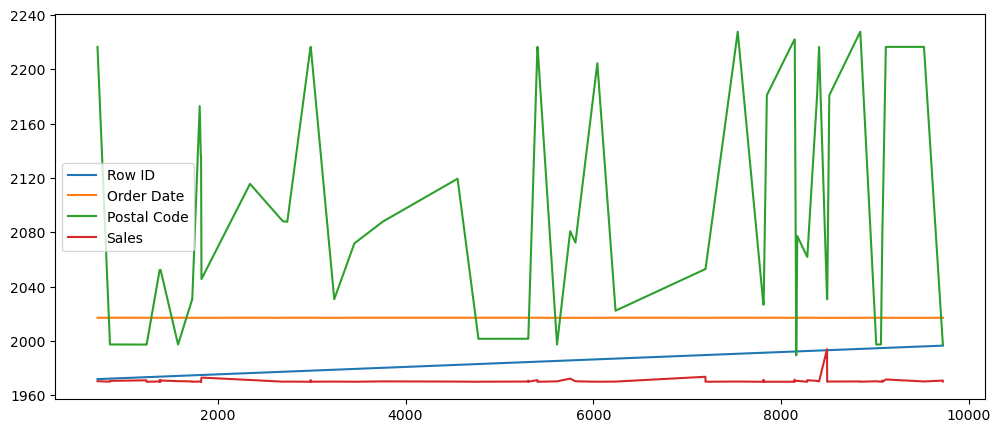

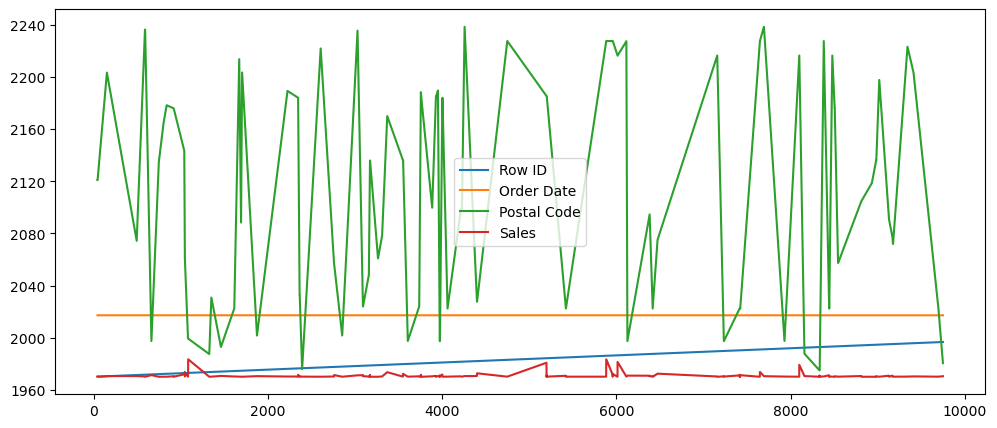

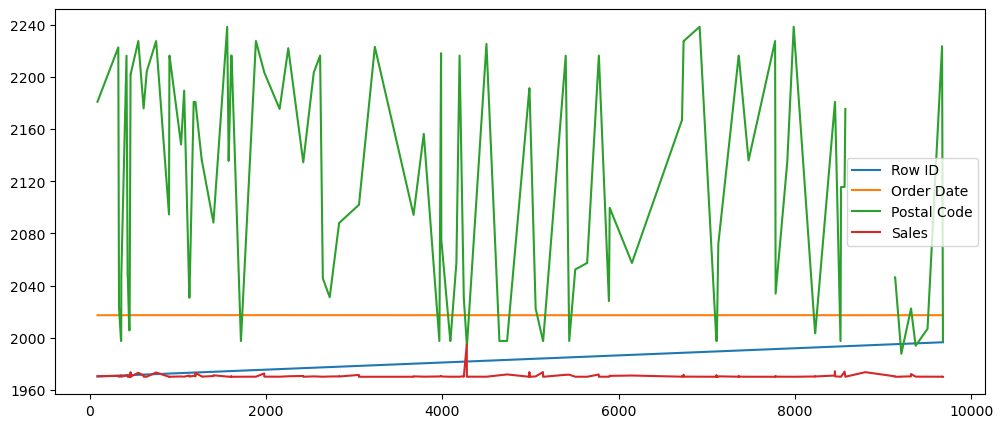

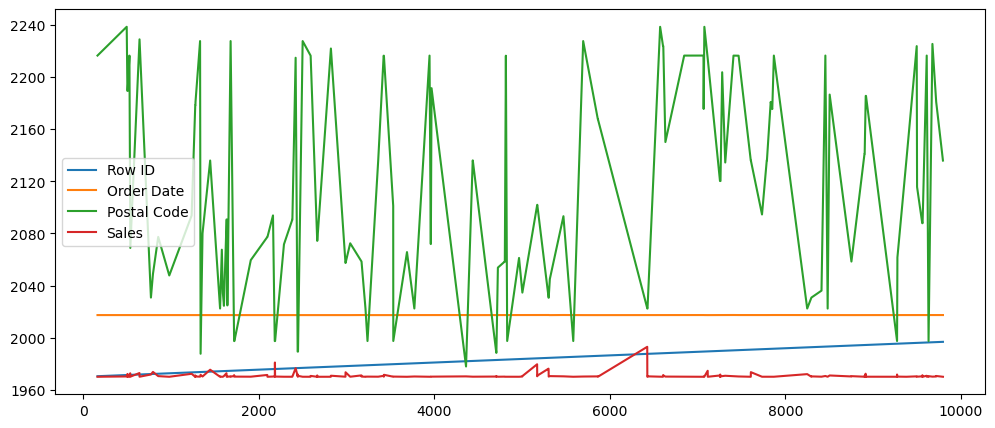

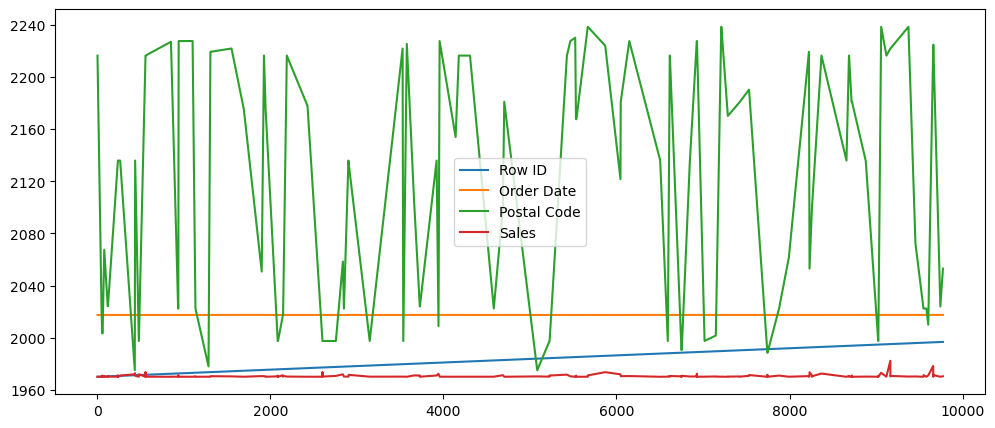

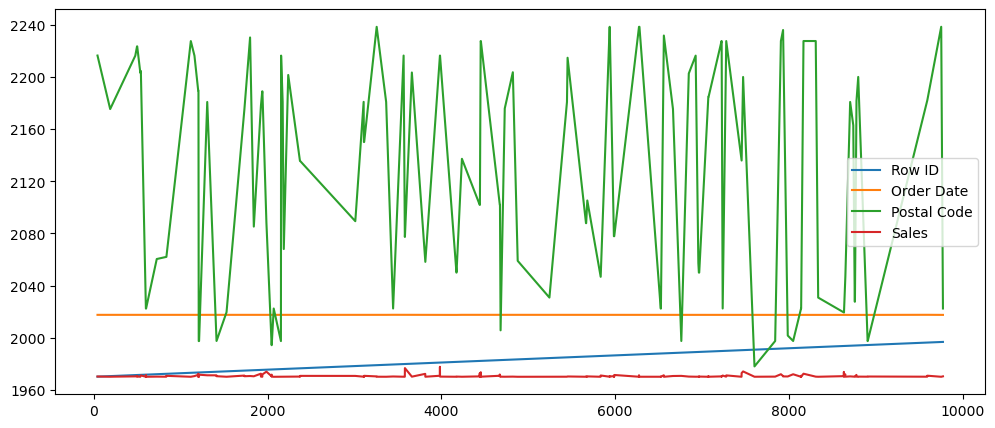

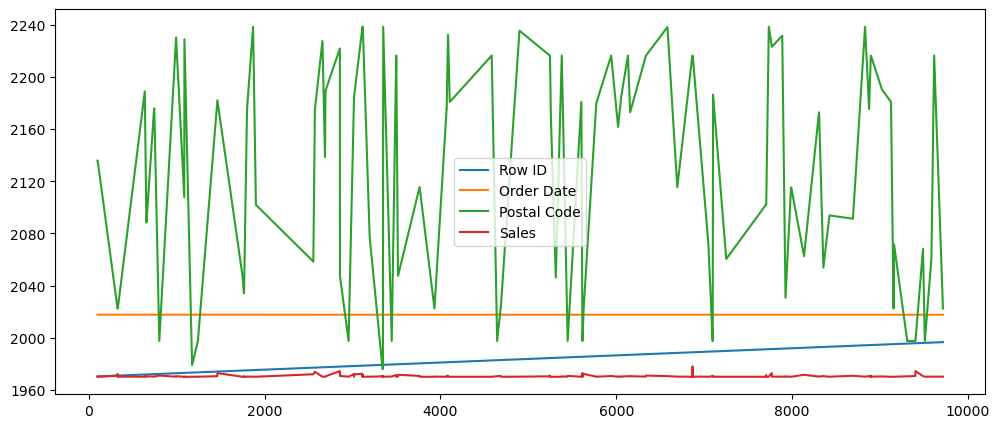

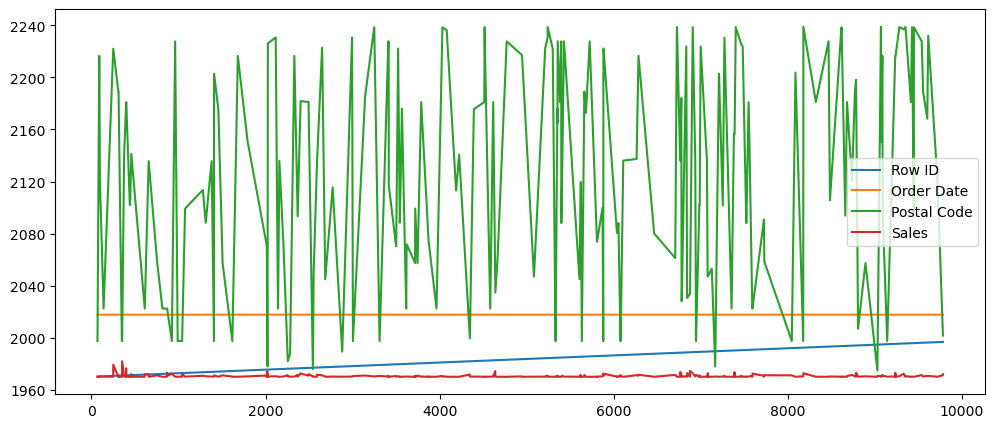

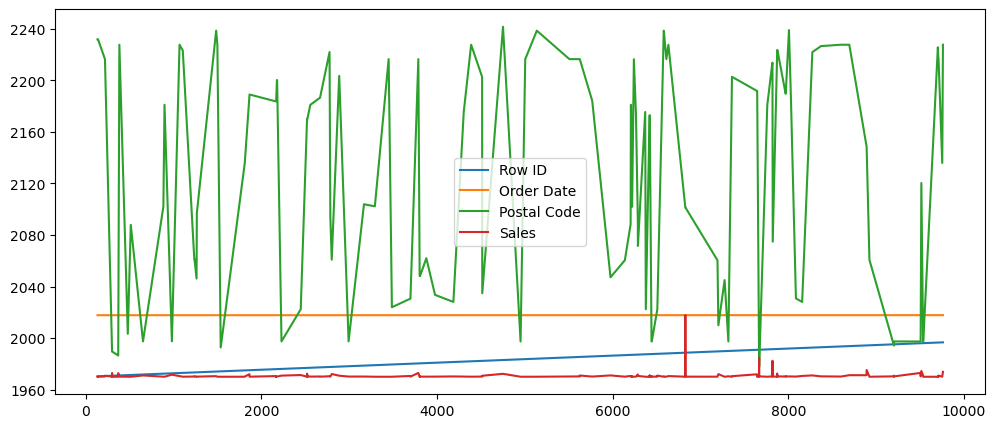

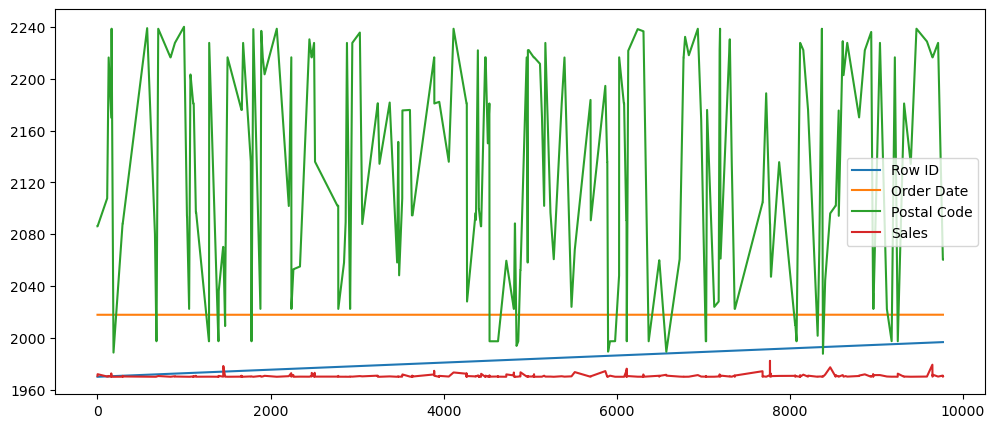

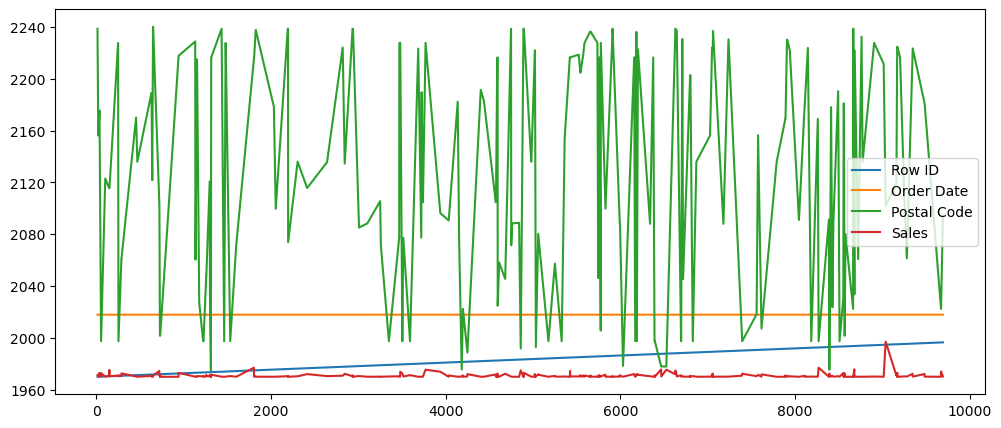

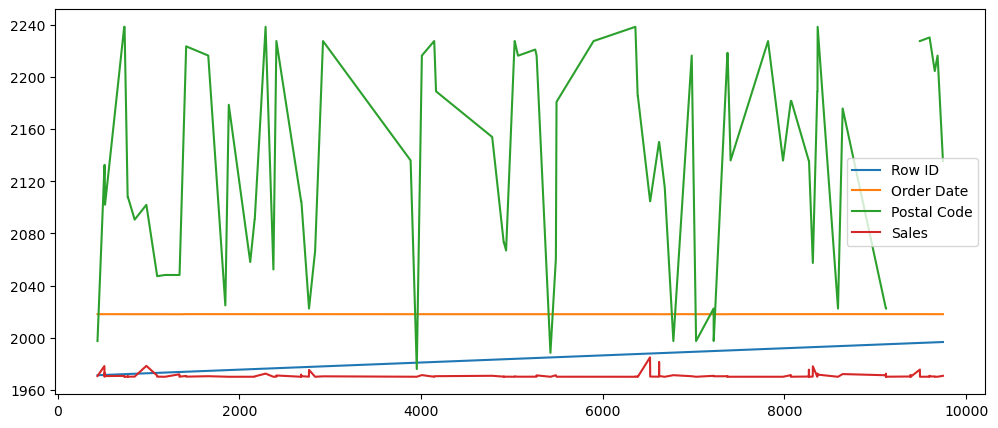

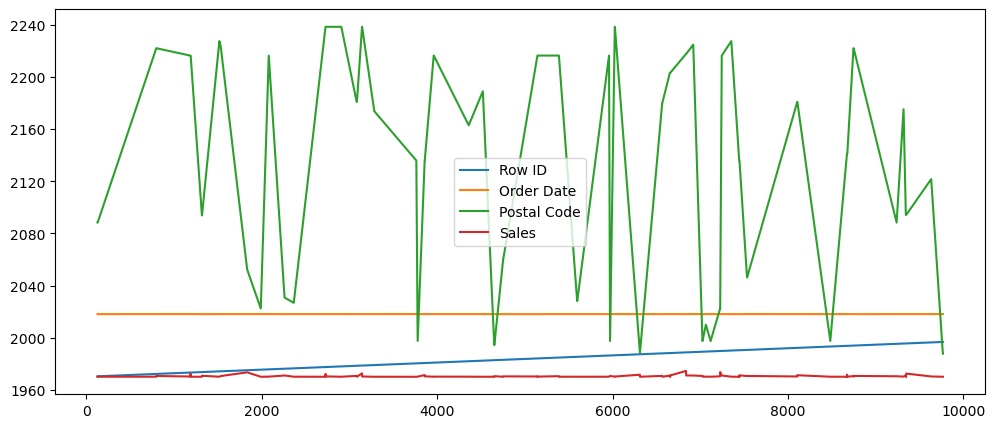

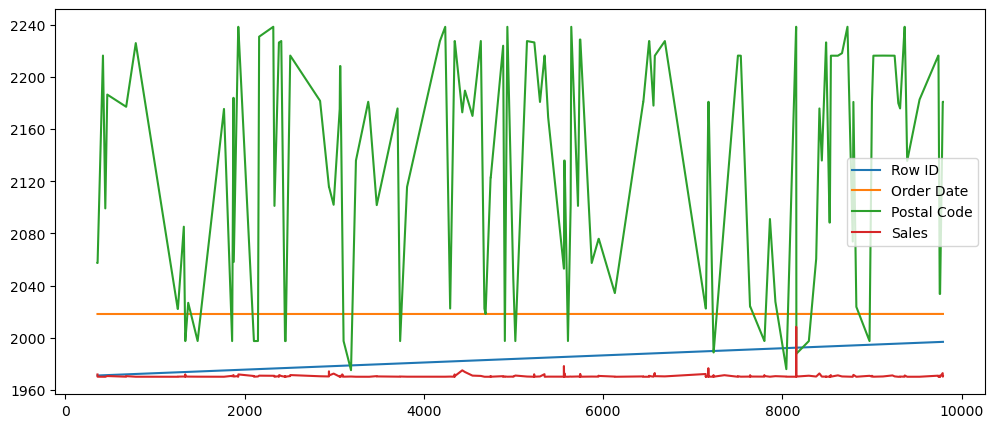

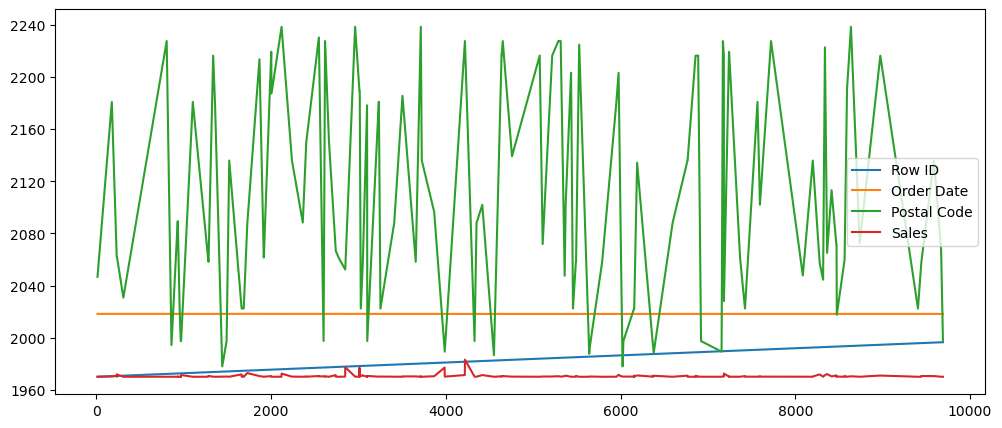

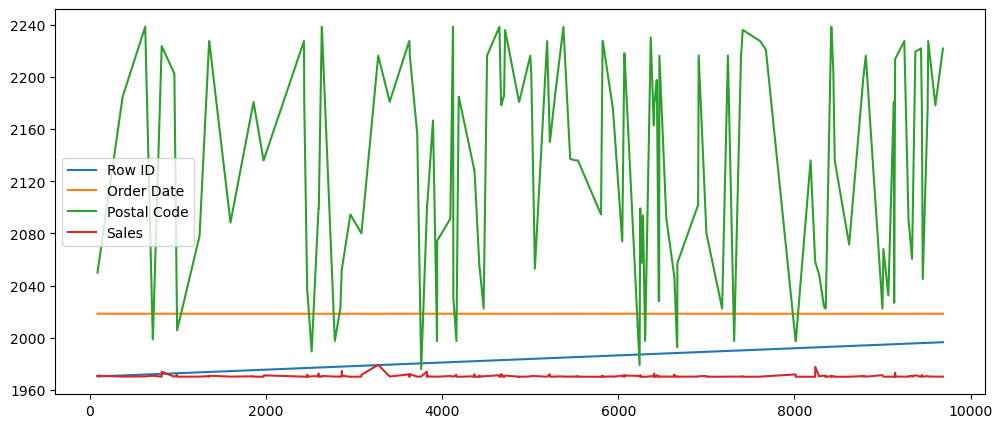

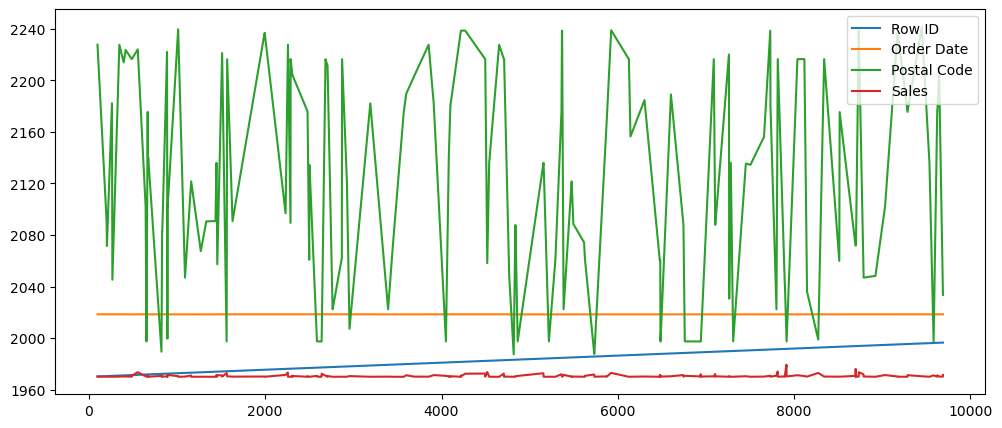

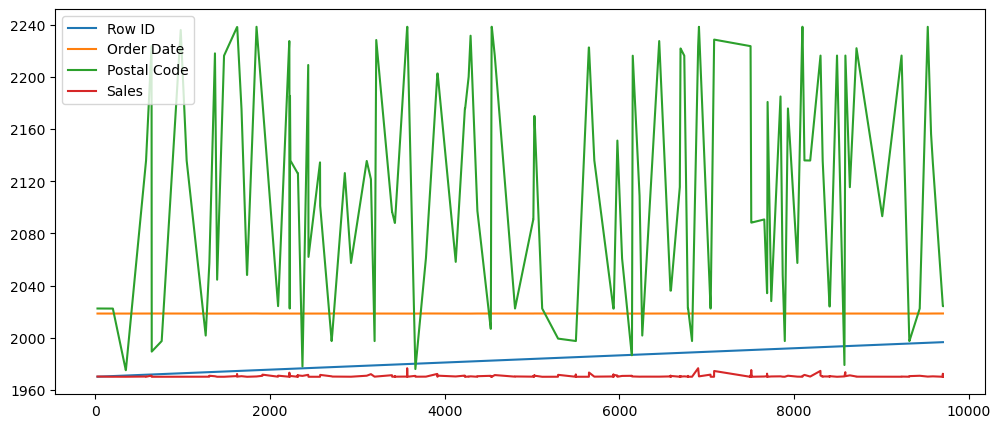

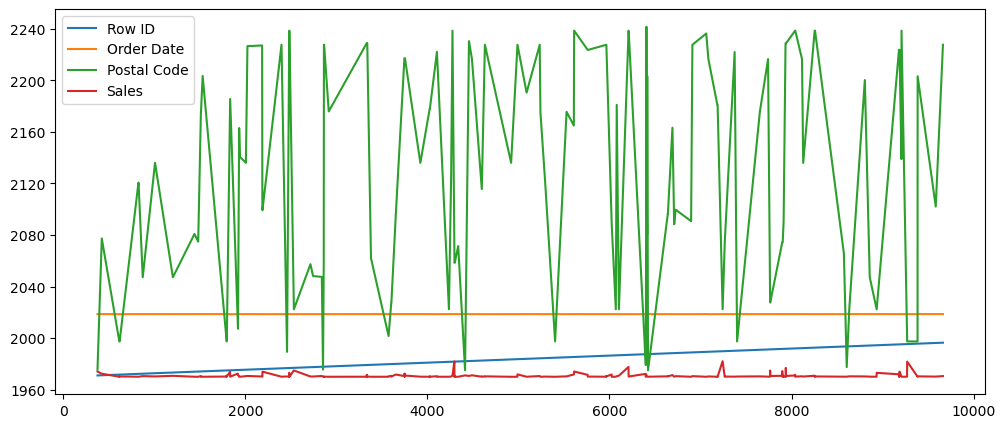

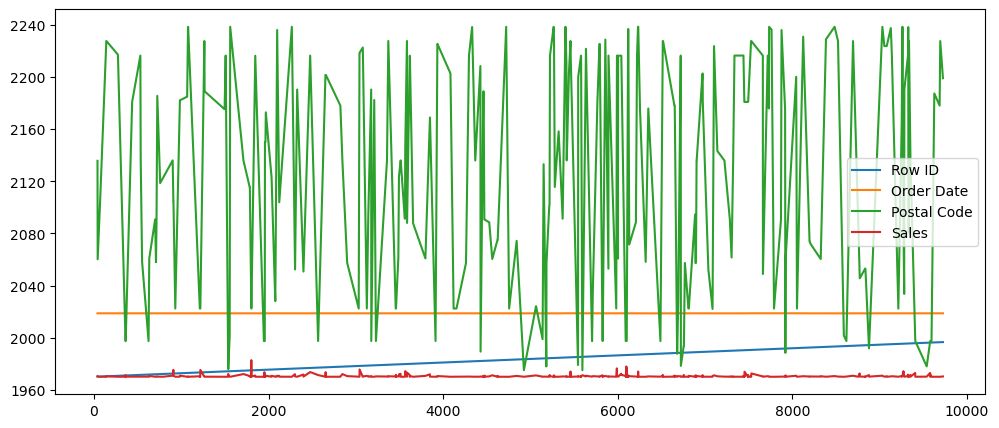

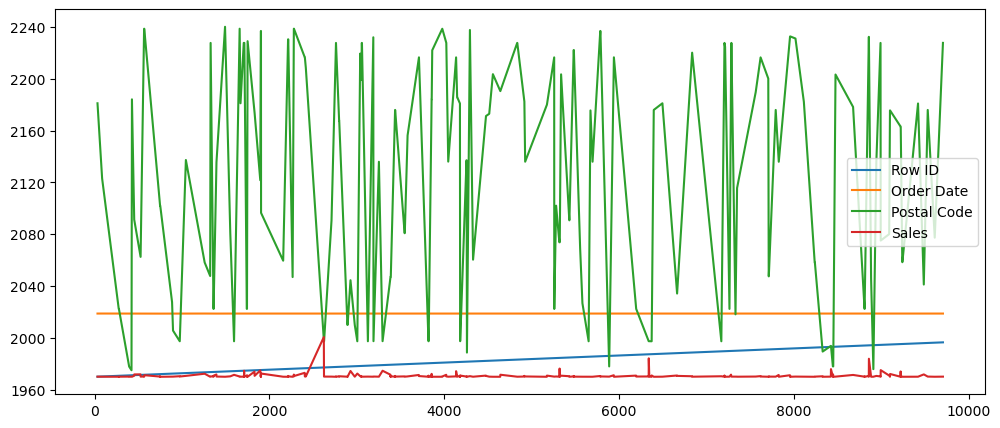

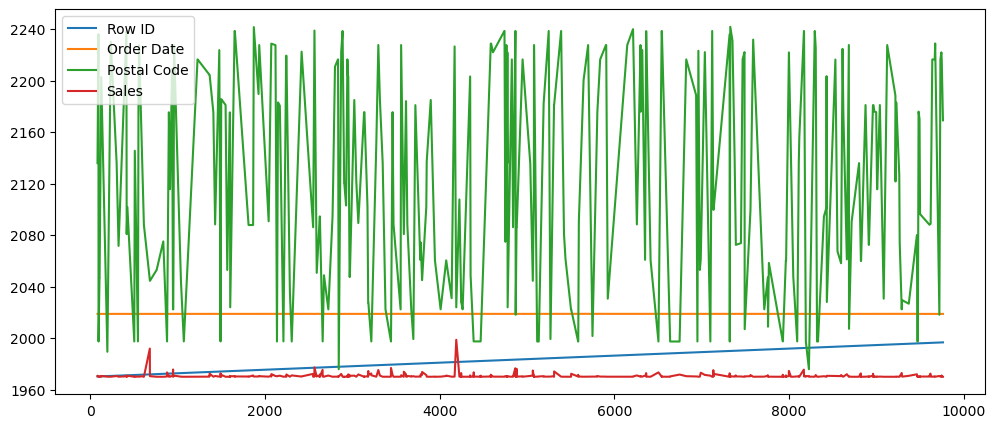

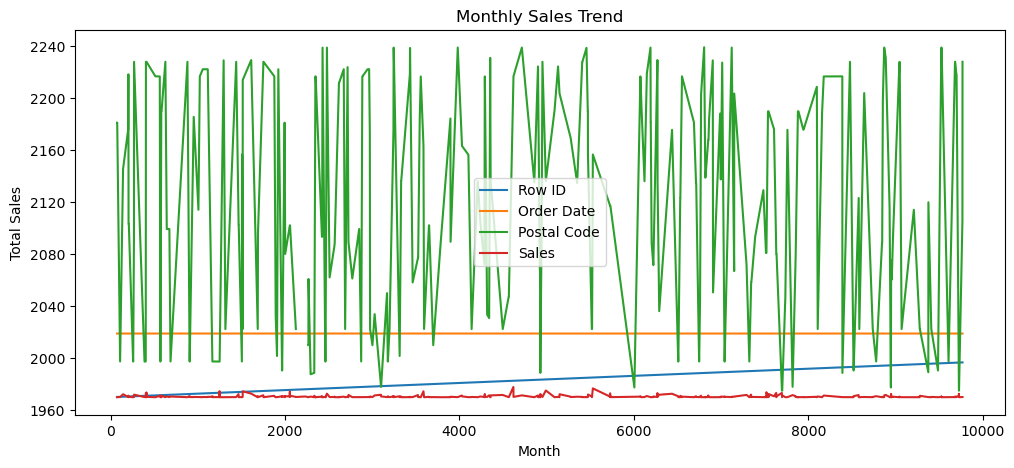

In [37]:
monthly_sales.plot(figsize=(12,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

In [38]:
plt.clf() 

<Figure size 640x480 with 0 Axes>

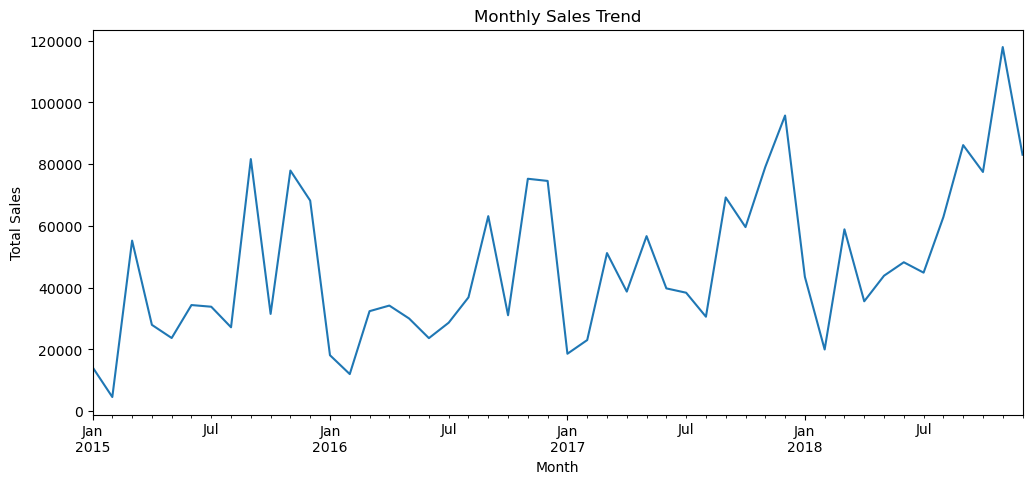

In [46]:
monthly_sales.plot(figsize=(12,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

In [40]:
 print(type(monthly_sales))

<class 'pandas.api.typing.DataFrameGroupBy'>


In [47]:
quaterly_sales = df.groupby(df['Order Date'].dt.to_period('Q'))['Sales'].sum()
print(quaterly_sales.head())

Order Date
2015Q1     73931.3960
2015Q2     85874.0936
2015Q3    142522.6063
2015Q4    177528.1122
2016Q1     62357.6870
Freq: Q-DEC, Name: Sales, dtype: float64


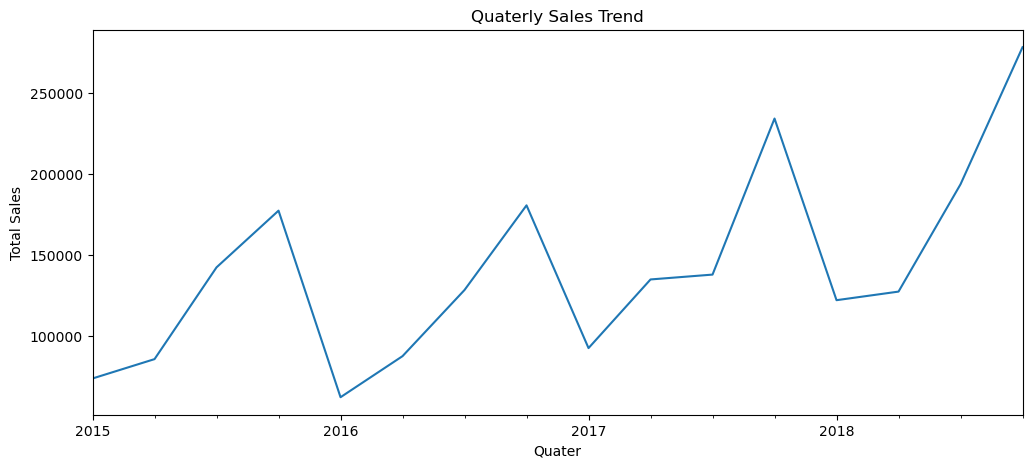

In [48]:
quaterly_sales.plot(figsize=(12,5))
plt.title('Quaterly Sales Trend')
plt.xlabel('Quater')
plt.ylabel('Total Sales')
plt.show()

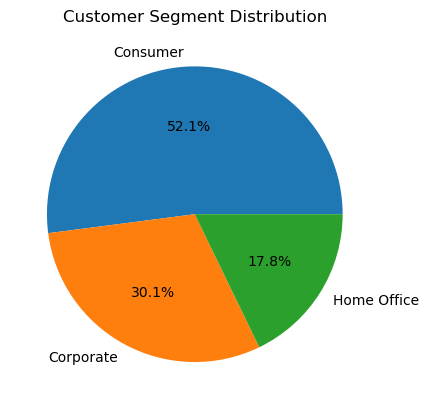

In [56]:
segment_sales = df.groupby('Segment')['Sales'].sum()

df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Customer Segment Distribution')
plt.ylabel('')
plt.show()

In [53]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [59]:
category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)
category_pct = (category_sales / category_sales.sum()) * 100
print(category_pct.round(2))

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64
Category
Furniture          32.22
Office Supplies    31.19
Technology         36.59
Name: Sales, dtype: float64


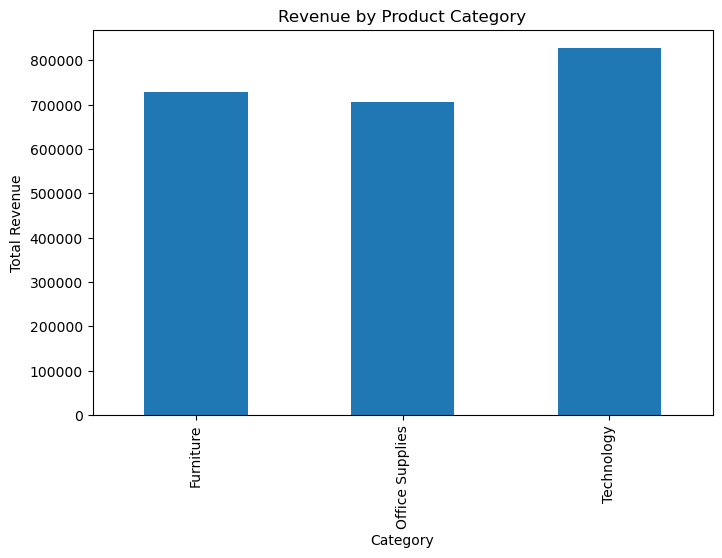

In [60]:
category_sales.plot(kind='bar', figsize=(8,5))
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.show()

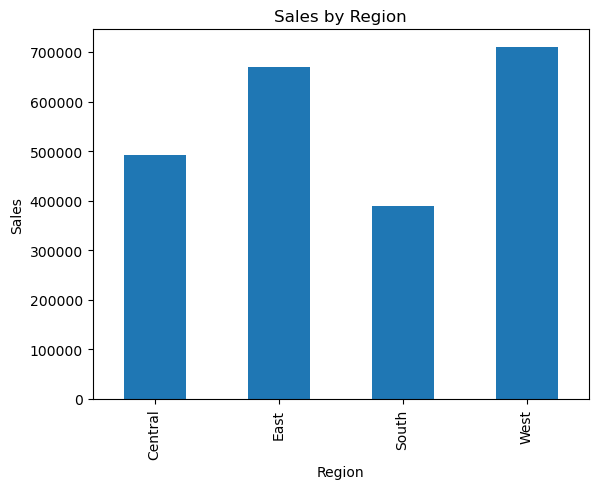

In [62]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

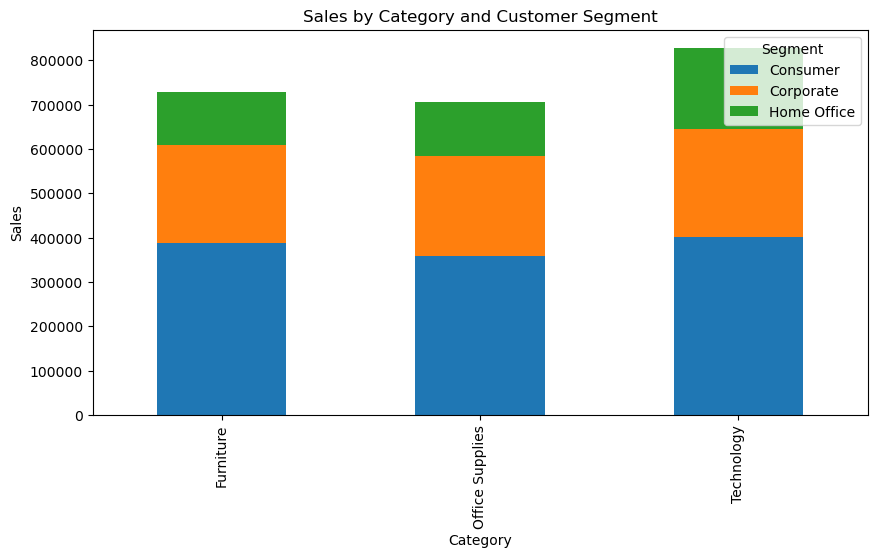

In [63]:
category_segment = df.groupby(['Category', 'Segment'])['Sales'].sum().unstack()

category_segment.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)

plt.title('Sales by Category and Customer Segment')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.legend(title='Segment')
plt.show()
